# XGBoost (1/2) — Breast Cancer Classification

**Idea:** XGBoost is gradient boosting (trees that fix the previous trees' mistakes) made faster, regularised and easier to use. Here we use it to tell **benign** from **malignant** tumours.

**In this notebook**
1. Load the breast cancer data and look at it
2. Clean it: drop the ID column and encode the labels as 0/1 (why XGBoost needs this)
3. Train an `XGBClassifier` with default settings
4. Evaluate: confusion matrix, accuracy, classification report
5. 10-fold cross-validation
6. Feature importance
7. Compare with Random Forest and Gradient Boosting (honest numbers)

> 📖 Theory: [`theory.md`](theory.md) §1, §3, §10, §12 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
print('xgboost version:', xgboost.__version__)

xgboost version: 3.2.0


## 1. Load the data

Each row is one tumour sample (Wisconsin breast cancer data). A doctor scored 9 cell properties on a scale of **1 to 10**.
The target `Class` is **2 = benign** (not cancer) or **4 = malignant** (cancer).

> ✍️ **Core code: learn this.** Load the CSV and look at it.

In [2]:
df = pd.read_csv('breast_cancer.csv')
print(df.shape)
df.head()

(683, 11)


,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [3]:
print(df['Class'].value_counts())
print('Missing values:', df.isna().sum().sum())

Class
2    444
4    239
Name: count, dtype: int64
Missing values: 0


683 samples, no missing values. About two thirds are benign (`2`) and one third malignant (`4`): a little imbalanced, but not much.

## 2. Clean the data: two bugs in the original course code

The original notebook did `X = dataset.iloc[:, :-1]` and fed `y` straight into `XGBClassifier`. That has **two problems**:

| Problem | Why it is wrong | Fix |
|---|---|---|
| `Sample code number` used as a feature | It is just an **ID** (a label on the sample). It carries no medical meaning; a model may still find fake patterns in it | drop it |
| Labels are `2` and `4` | Modern XGBoost (≥ 1.6) requires class labels **0, 1, …, n-1** | map `2 → 0`, `4 → 1` |

Let's first *see* the label error (we catch it so the notebook keeps running):

In [4]:
X_raw = df.drop(columns=['Sample code number', 'Class'])
try:
    XGBClassifier().fit(X_raw, df['Class'])          # labels are 2 and 4
except ValueError as e:
    print('ValueError:', str(e).split('\n')[0][:150])

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [2 4]


XGBoost refuses labels `[2 4]` and asks for `[0 1]`. So we encode them.

> ✍️ **Core code: learn this.** Drop the ID column and encode the labels to 0/1.

In [5]:
X = df.drop(columns=['Sample code number', 'Class'])   # 9 cell features
y = df['Class'].map({2: 0, 4: 1})                        # 0 = benign, 1 = malignant

print(X.shape)
print(y.value_counts().rename({0: 'benign (0)', 1: 'malignant (1)'}))

(683, 9)
Class
benign (0)       444
malignant (1)    239
Name: count, dtype: int64


> 💡 `sklearn.preprocessing.LabelEncoder` does the same job automatically (`2 → 0`, `4 → 1`). A simple `.map()` is clearer here because we can see exactly what each number means.

## 3. Train / test split and the XGBoost model

Same split as the original course: 80% train, 20% test, `random_state=0`.

> ✍️ **Core code: learn this.** Split, create an `XGBClassifier` and fit it. Same `fit` / `predict` API as any scikit-learn model.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print('train:', X_train.shape, ' test:', X_test.shape)

xgb = XGBClassifier(random_state=0)    # default settings: 100 trees, max_depth=6, learning_rate=0.3
xgb.fit(X_train, y_train)

train: (546, 9)  test: (137, 9)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


The printout shows all the parameters. Most are `None`, which means "use XGBoost's built-in default"
(e.g. `n_estimators=100`, `max_depth=6`, `learning_rate=0.3`; see theory §5).

## 4. Evaluate on the test set

> ✍️ **Core code: learn this.** Predict, then compute the confusion matrix, accuracy and classification report.

In [7]:
y_pred = xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))

[[85  2]
 [ 2 48]]
Accuracy: 0.9708
              precision    recall  f1-score   support

      benign       0.98      0.98      0.98        87
   malignant       0.96      0.96      0.96        50

    accuracy                           0.97       137
   macro avg       0.97      0.97      0.97       137
weighted avg       0.97      0.97      0.97       137



> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

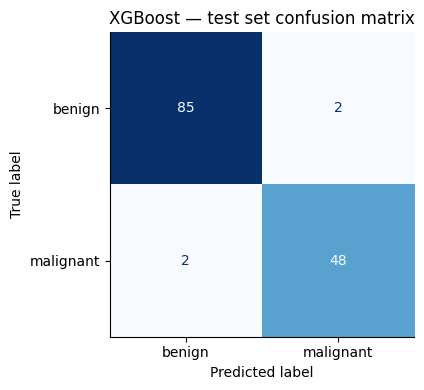

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=['benign', 'malignant']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('XGBoost — test set confusion matrix')
plt.tight_layout(); plt.show()

**Reading it:** rows are the true class, columns the predicted class.
XGBoost got **133 of 137** test samples right (**accuracy 0.9708**): 2 benign tumours were flagged as malignant (false alarms) and **2 malignant tumours were missed** (false negatives). In medicine the missed cancers are the costly mistake, so recall for `malignant` (0.96 here) matters more than plain accuracy.

## 5. 10-fold cross-validation

One test set of 137 samples is small: a lucky or unlucky split can move accuracy by a few percent.
**k-fold cross-validation** trains and tests 10 times on different folds of the training data and averages the scores.

> ✍️ **Core code: learn this.** `cross_val_score` works with XGBoost exactly as with scikit-learn models.

In [9]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
scores = cross_val_score(XGBClassifier(random_state=0), X_train, y_train, cv=cv)
print('Fold accuracies:', scores.round(3))
print(f'Accuracy: {scores.mean()*100:.2f} %   Standard deviation: {scores.std()*100:.2f} %')

Fold accuracies: [0.982 0.927 0.982 0.945 0.982 0.982 0.963 0.963 0.981 0.944]
Accuracy: 96.52 %   Standard deviation: 1.91 %


The 10 fold scores range from about 0.93 to 0.98. The average is **96.52 % ± 1.91 %**, close to the 97.08 % test accuracy, so the test result was not just a lucky split.

## 6. Feature importance

XGBoost can tell us which features its trees relied on. In the scikit-learn API, `feature_importances_` uses
**gain** by default: how much a feature improved the objective, on average, when the trees split on it.

> ✍️ **Core code: learn this.** Read `feature_importances_` and sort it.

In [10]:
imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.round(3)

Uniformity of Cell Size        0.437
Uniformity of Cell Shape       0.211
Single Epithelial Cell Size    0.151
Bare Nuclei                    0.087
Bland Chromatin                0.046
Clump Thickness                0.028
Normal Nucleoli                0.022
Marginal Adhesion              0.019
Mitoses                        0.000
dtype: float32

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

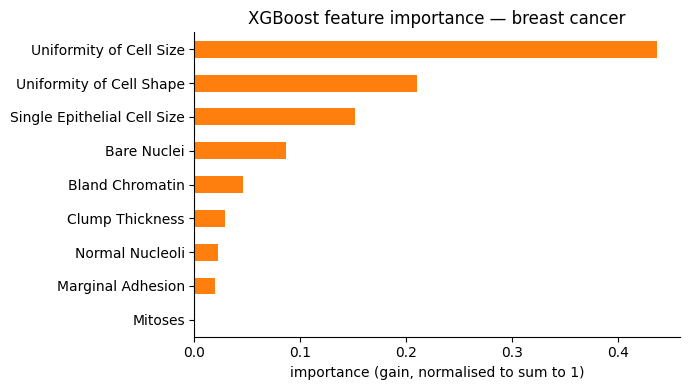

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
imp.sort_values().plot.barh(ax=ax, color='tab:orange')
ax.set_xlabel('importance (gain, normalised to sum to 1)')
ax.set_title('XGBoost feature importance — breast cancer')
plt.tight_layout(); plt.show()

**Uniformity of Cell Size** dominates (0.437), followed by **Uniformity of Cell Shape** (0.211) and **Single Epithelial Cell Size** (0.151). **Mitoses** has importance ≈ 0: the trees practically never used it.

> ⚠️ Importance shows what *this model* used, not what *causes* cancer. Correlated features (cell size and cell shape are strongly related) share or "steal" importance from each other.

## 7. XGBoost vs Random Forest vs Gradient Boosting

Is XGBoost really better? Let's compare three tree ensembles with default settings on the **same** split and the **same** 10 CV folds.

> ✍️ **Core code: learn this.** Loop over models, record test accuracy and 10-fold CV accuracy.

In [12]:
models = {
    'XGBoost':           XGBClassifier(random_state=0),
    'Random Forest':     RandomForestClassifier(random_state=0),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv)
    rows.append([name, test_acc, cv_scores.mean(), cv_scores.std()])

results = pd.DataFrame(rows, columns=['model', 'test accuracy', 'CV mean', 'CV std']).set_index('model')
results.round(4)

,test accuracy,CV mean,CV std
model,,,
XGBoost,0.9708,0.9652,0.0191
Random Forest,0.9708,0.9689,0.0216
Gradient Boosting,0.9562,0.9597,0.0229


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

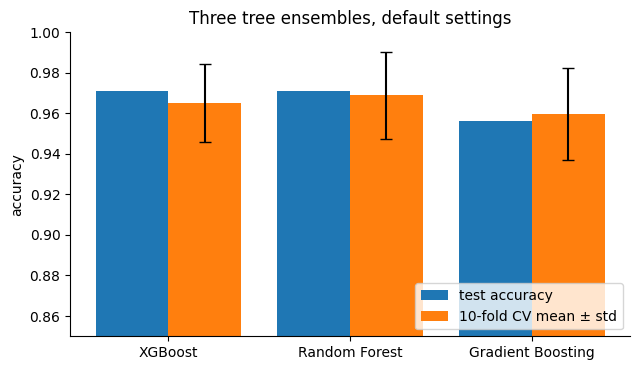

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
x = np.arange(len(results))
ax.bar(x - 0.2, results['test accuracy'], width=0.4, label='test accuracy')
ax.bar(x + 0.2, results['CV mean'], width=0.4, yerr=results['CV std'], capsize=4, label='10-fold CV mean ± std')
ax.set_xticks(x); ax.set_xticklabels(results.index)
ax.set_ylim(0.85, 1.0); ax.set_ylabel('accuracy')
ax.set_title('Three tree ensembles, default settings')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

**Honest result:** the three models are practically tied.

| Model | Test accuracy | 10-fold CV |
|---|:-:|:-:|
| XGBoost | 0.9708 | 0.965 ± 0.019 |
| Random Forest | 0.9708 | **0.969** ± 0.022 |
| Gradient Boosting | 0.9562 | 0.960 ± 0.023 |

XGBoost and Random Forest have the same test accuracy, and Random Forest is even slightly higher in CV. The differences (≤ 1%) are smaller than the CV standard deviation (~2%), so **none of them is clearly better**.
This dataset is small (683 rows) and easy, so any good tree ensemble reaches ~96–97%. XGBoost's real advantages show up on bigger, harder problems with tuning and early stopping (next notebook).

## Key takeaways
- `XGBClassifier` uses the familiar scikit-learn API: `fit`, `predict`, `cross_val_score` all just work.
- Modern XGBoost needs class labels **0 … n-1**: encode `2/4` → `0/1` first.
- Always **drop ID columns**: they are labels, not information.
- Default XGBoost: **0.9708** test accuracy, **96.5% ± 1.9%** in 10-fold CV. Random Forest scored the same; on this small, easy dataset XGBoost is **not** clearly better.
- XGBoost shines most on **larger, messier** tabular data with tuning and early stopping. That is the next notebook.

## 🧠 Quick check

<details><summary>1. Why did the original code crash with XGBoost 3.x?</summary>
The target had values 2 and 4. XGBoost's classifier requires labels 0, 1, …, n-1, so they must be encoded (2 → 0, 4 → 1).
</details>

<details><summary>2. Why should <code>Sample code number</code> not be a feature?</summary>
It is an identifier, not a measurement. It has no medical meaning, and any pattern the model finds in it is accidental (or leakage from how samples were numbered).
</details>

<details><summary>3. Why use 10-fold cross-validation in addition to the test set?</summary>
The test set has only 137 samples, so one split gives a noisy estimate. Averaging over 10 folds gives a more reliable number and also shows the spread (standard deviation).
</details>

<details><summary>4. XGBoost, Random Forest and Gradient Boosting scored almost the same here. Does that mean XGBoost is useless?</summary>
No. On a small, clean dataset any good tree ensemble does well. XGBoost's advantages (speed, regularisation, early stopping, missing-value handling) matter more on larger, harder data and when you tune it.
</details>

➡️ **Next:** [`02-xgboost-churn.ipynb`](02-xgboost-churn.ipynb): a realistic project with early stopping, imbalance and tuning.